# CardVision: Blackjack Practice Coach

**Project:** CardVision  
**Student:** Dylan Legault  
**Course:** ITAI 1378 – Computer Vision Systems Development  
**Tier:** Tier 2  

CardVision is a computer vision blackjack practice assistant. The system detects card ranks from a blackjack board image, assigns cards to dealer/player zones, parses the board state, and recommends a V1 basic strategy action: **Hit, Stand, Double, or Split**.

In [2]:
# Cell 2 - Install dependencies

!pip install kagglehub ultralytics -q

print("Dependencies installed.")

Dependencies installed.


In [3]:
# Cell 3 - Imports

import os
import random
import yaml
import shutil
from pathlib import Path
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image, ImageDraw
from tqdm import tqdm

import torch
import kagglehub
from ultralytics import YOLO

print("Imports complete.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Imports complete.


In [4]:
# Cell 4 - Verify GPU

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. In Colab: Runtime -> Change runtime type -> GPU")

CUDA Available: True
GPU: Tesla T4


In [5]:
# Cell 5 - Card values and parser utilities

CARD_VALUES = {
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6": 6,
    "7": 7,
    "8": 8,
    "9": 9,
    "10": 10,
    "J": 10,
    "Q": 10,
    "K": 10,
    "A": 11,
}

VALID_RANKS = set(CARD_VALUES.keys())

def normalize_rank(rank: str) -> str:
    rank = str(rank).strip().upper()
    if rank not in VALID_RANKS:
        raise ValueError(f"Invalid rank: {rank}. Use one of: {sorted(VALID_RANKS)}")
    return rank


def parse_card_input(card_text: str) -> List[str]:
    cards = [card.strip() for card in card_text.split(",") if card.strip()]
    if not cards:
        raise ValueError("No cards were entered.")
    return [normalize_rank(card) for card in cards]

In [6]:
# Cell 6 - Blackjack hand parser

def hand_total(cards: List[str]) -> Tuple[int, bool]:
    ranks = [normalize_rank(card) for card in cards]
    total = sum(CARD_VALUES[rank] for rank in ranks)
    aces = ranks.count("A")

    while total > 21 and aces > 0:
        total -= 10
        aces -= 1

    is_soft = any(rank == "A" for rank in ranks) and total <= 21 and aces > 0
    return total, is_soft


def is_pair(cards: List[str]) -> bool:
    ranks = [normalize_rank(card) for card in cards]
    return len(ranks) == 2 and ranks[0] == ranks[1]


def describe_hand(cards: List[str]) -> Dict:
    total, soft = hand_total(cards)
    pair = is_pair(cards)

    if pair:
        hand_type = "pair"
    elif soft:
        hand_type = "soft"
    else:
        hand_type = "hard"

    return {
        "cards": [normalize_rank(card) for card in cards],
        "total": total,
        "is_soft": soft,
        "is_pair": pair,
        "hand_type": hand_type,
    }

In [7]:
# Cell 7 - V1 basic strategy recommendation engine

def dealer_value(rank: str) -> int:
    rank = normalize_rank(rank)
    if rank == "A":
        return 11
    return CARD_VALUES[rank]


def recommend_action(player_cards: List[str], dealer_upcard: str) -> str:
    player_cards = [normalize_rank(card) for card in player_cards]
    dealer = dealer_value(dealer_upcard)
    info = describe_hand(player_cards)
    total = info["total"]

    # Pair strategy
    if info["is_pair"]:
        pair_rank = player_cards[0]

        if pair_rank in ["A", "8"]:
            return "Split"
        if pair_rank in ["10", "J", "Q", "K"]:
            return "Stand"
        if pair_rank == "9":
            return "Split" if dealer in [2, 3, 4, 5, 6, 8, 9] else "Stand"
        if pair_rank == "7":
            return "Split" if dealer in [2, 3, 4, 5, 6, 7] else "Hit"
        if pair_rank == "6":
            return "Split" if dealer in [2, 3, 4, 5, 6] else "Hit"
        if pair_rank == "5":
            return "Double" if dealer in [2, 3, 4, 5, 6, 7, 8, 9] else "Hit"
        if pair_rank == "4":
            return "Hit"
        if pair_rank in ["2", "3"]:
            return "Split" if dealer in [2, 3, 4, 5, 6, 7] else "Hit"

    # Soft totals
    if info["is_soft"]:
        if total >= 20:
            return "Stand"
        if total == 19:
            return "Double" if dealer == 6 else "Stand"
        if total == 18:
            if dealer in [3, 4, 5, 6]:
                return "Double"
            if dealer in [2, 7, 8]:
                return "Stand"
            return "Hit"
        if total in [16, 17]:
            return "Double" if dealer in [4, 5, 6] else "Hit"
        if total in [14, 15]:
            return "Double" if dealer in [5, 6] else "Hit"
        if total == 13:
            return "Double" if dealer in [5, 6] else "Hit"

    # Hard totals
    if total >= 17:
        return "Stand"
    if 13 <= total <= 16:
        return "Stand" if dealer in [2, 3, 4, 5, 6] else "Hit"
    if total == 12:
        return "Stand" if dealer in [4, 5, 6] else "Hit"
    if total == 11:
        return "Double"
    if total == 10:
        return "Double" if dealer in [2, 3, 4, 5, 6, 7, 8, 9] else "Hit"
    if total == 9:
        return "Double" if dealer in [3, 4, 5, 6] else "Hit"

    return "Hit"


def cardvision_recommend(player_cards: List[str], dealer_upcard: str) -> Dict:
    player_cards = [normalize_rank(card) for card in player_cards]
    dealer_upcard = normalize_rank(dealer_upcard)

    hand_info = describe_hand(player_cards)
    action = recommend_action(player_cards, dealer_upcard)

    return {
        "player_cards": hand_info["cards"],
        "player_total": hand_info["total"],
        "hand_type": hand_info["hand_type"],
        "dealer_upcard": dealer_upcard,
        "recommended_action": action,
    }


def show_cardvision_result(result: Dict):
    return pd.DataFrame([result])

In [8]:
# Cell 8 - Strategy engine test cases

test_cases = [
    (["A", "7"], "6"),
    (["10", "6"], "10"),
    (["8", "8"], "A"),
    (["10", "10"], "6"),
    (["9", "2"], "5"),
    (["5", "5"], "6"),
    (["A", "6"], "2"),
    (["10", "2"], "4"),
]

for player, dealer in test_cases:
    result = cardvision_recommend(player, dealer)
    print(f"Player: {player} | Dealer: {dealer} -> {result}")

show_cardvision_result(cardvision_recommend(["10", "2"], "5"))

Player: ['A', '7'] | Dealer: 6 -> {'player_cards': ['A', '7'], 'player_total': 18, 'hand_type': 'soft', 'dealer_upcard': '6', 'recommended_action': 'Double'}
Player: ['10', '6'] | Dealer: 10 -> {'player_cards': ['10', '6'], 'player_total': 16, 'hand_type': 'hard', 'dealer_upcard': '10', 'recommended_action': 'Hit'}
Player: ['8', '8'] | Dealer: A -> {'player_cards': ['8', '8'], 'player_total': 16, 'hand_type': 'pair', 'dealer_upcard': 'A', 'recommended_action': 'Split'}
Player: ['10', '10'] | Dealer: 6 -> {'player_cards': ['10', '10'], 'player_total': 20, 'hand_type': 'pair', 'dealer_upcard': '6', 'recommended_action': 'Stand'}
Player: ['9', '2'] | Dealer: 5 -> {'player_cards': ['9', '2'], 'player_total': 11, 'hand_type': 'hard', 'dealer_upcard': '5', 'recommended_action': 'Double'}
Player: ['5', '5'] | Dealer: 6 -> {'player_cards': ['5', '5'], 'player_total': 10, 'hand_type': 'pair', 'dealer_upcard': '6', 'recommended_action': 'Double'}
Player: ['A', '6'] | Dealer: 2 -> {'player_cards'

,player_cards,player_total,hand_type,dealer_upcard,recommended_action
0,"[10, 2]",12,hard,5,Stand


In [9]:
# Cell 9 - Download Kaggle 52-card PNG dataset

path = kagglehub.dataset_download("avinashtare/complete-52-card-deck-dataset-for-card-game")

KAGGLE_DATASET_PATH = Path(path)

print("Dataset path:", KAGGLE_DATASET_PATH)

100%|██████████| 930k/930k [00:00<00:00, 22.1MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/avinashtare/complete-52-card-deck-dataset-for-card-game/versions/1


In [10]:
# Cell 10 - Locate card image files

all_files = list(KAGGLE_DATASET_PATH.rglob("*"))

image_files = sorted([
    p for p in all_files
    if p.suffix.lower() in [".png", ".jpg", ".jpeg"]
])

print("Image files found:", len(image_files))

for p in image_files[:20]:
    print(p.name)

Image files found: 52
C10.png
C2.png
C3.png
C4.png
C5.png
C6.png
C7.png
C8.png
C9.png
CA.png
CJ.png
CK.png
CQ.png
D10.png
D2.png
D3.png
D4.png
D5.png
D6.png
D7.png


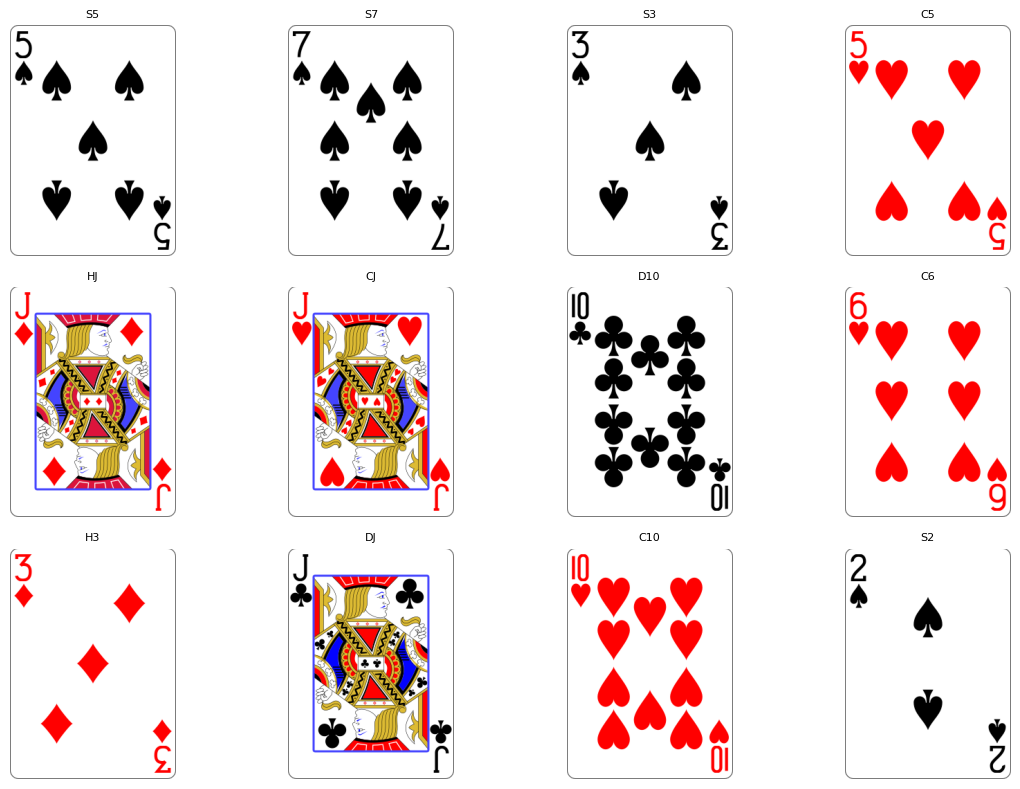

In [11]:
# Cell 11 - Preview raw card images

sample_images = random.sample(image_files, min(12, len(image_files)))

plt.figure(figsize=(12, 8))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path).convert("RGBA")
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(img_path.stem, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# Cell 12 - Parse Kaggle card file names into full card labels

SUIT_PREFIXES = {
    "C": "C",
    "D": "D",
    "H": "H",
    "S": "S",
}

VALID_RANKS_FOR_FILES = {"A", "2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K"}

def parse_card_class_from_filename(file_path):
    stem = file_path.stem.upper().strip()

    if len(stem) < 2:
        return None

    suit = stem[0]
    rank = stem[1:]

    if suit not in SUIT_PREFIXES:
        return None

    if rank not in VALID_RANKS_FOR_FILES:
        return None

    return f"{rank}{suit}"


parsed = [(p, parse_card_class_from_filename(p)) for p in image_files]

valid_cards = [(p, label) for p, label in parsed if label is not None]
invalid_cards = [(p, label) for p, label in parsed if label is None]

CARD_CLASSES = sorted([label for _, label in valid_cards])
class_to_id = {cls_name: idx for idx, cls_name in enumerate(CARD_CLASSES)}
id_to_class = {idx: cls_name for cls_name, idx in class_to_id.items()}

print("Valid parsed cards:", len(valid_cards))
print("Invalid/unparsed files:", len(invalid_cards))
print("Number of full card classes:", len(CARD_CLASSES))
print(CARD_CLASSES)

Valid parsed cards: 52
Invalid/unparsed files: 0
Number of full card classes: 52
['10C', '10D', '10H', '10S', '2C', '2D', '2H', '2S', '3C', '3D', '3H', '3S', '4C', '4D', '4H', '4S', '5C', '5D', '5H', '5S', '6C', '6D', '6H', '6S', '7C', '7D', '7H', '7S', '8C', '8D', '8H', '8S', '9C', '9D', '9H', '9S', 'AC', 'AD', 'AH', 'AS', 'JC', 'JD', 'JH', 'JS', 'KC', 'KD', 'KH', 'KS', 'QC', 'QD', 'QH', 'QS']


Rank-Only YOLO Dataset

In [13]:
# Cell 13 - Rank-only class mapping

RANK_CLASSES = ["A", "2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K"]

rank_to_id = {rank: idx for idx, rank in enumerate(RANK_CLASSES)}
id_to_rank = {idx: rank for rank, idx in rank_to_id.items()}

def label_to_rank(card_label):
    card_label = card_label.upper().strip()
    if card_label.startswith("10"):
        return "10"
    return card_label[0]


for example in ["9D", "9H", "AH", "10C", "QS"]:
    print(example, "->", label_to_rank(example))

9D -> 9
9H -> 9
AH -> A
10C -> 10
QS -> Q


In [14]:
# Cell 14 - Shared synthetic dataset utilities

IMG_W, IMG_H = 640, 640
CARD_W, CARD_H = 110, 160

card_asset_lookup = {label: p for p, label in valid_cards}

def resize_card(card_img):
    return card_img.convert("RGBA").resize((CARD_W, CARD_H))


def paste_card_and_get_bbox(canvas, card_path, x, y):
    card_img = Image.open(card_path).convert("RGBA")
    card_img = resize_card(card_img)

    canvas.alpha_composite(card_img, dest=(x, y))

    x_center = (x + CARD_W / 2) / IMG_W
    y_center = (y + CARD_H / 2) / IMG_H
    w_norm = CARD_W / IMG_W
    h_norm = CARD_H / IMG_H

    return x_center, y_center, w_norm, h_norm


print("Synthetic helpers ready.")
print("Card assets available:", len(card_asset_lookup))

Synthetic helpers ready.
Card assets available: 52


In [15]:
# Cell 15 - Generate rank-only synthetic blackjack YOLO dataset

RANK_SYNTH_ROOT = Path("/content/cardvision_yolo_rank")
RANK_TRAIN_IMG_DIR = RANK_SYNTH_ROOT / "images" / "train"
RANK_VAL_IMG_DIR = RANK_SYNTH_ROOT / "images" / "val"
RANK_TRAIN_LABEL_DIR = RANK_SYNTH_ROOT / "labels" / "train"
RANK_VAL_LABEL_DIR = RANK_SYNTH_ROOT / "labels" / "val"

for d in [RANK_TRAIN_IMG_DIR, RANK_VAL_IMG_DIR, RANK_TRAIN_LABEL_DIR, RANK_VAL_LABEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)


def create_rank_synthetic_blackjack_image(split, index):
    canvas = Image.new("RGBA", (IMG_W, IMG_H), (48, 102, 70, 255))
    draw = ImageDraw.Draw(canvas)

    draw.rectangle([0, 0, IMG_W, IMG_H], fill=(48, 102, 70, 255))
    draw.line([0, int(IMG_H * 0.45), IMG_W, int(IMG_H * 0.45)], fill=(230, 230, 230, 100), width=3)

    selected_cards = random.sample(CARD_CLASSES, 3)

    dealer_card = selected_cards[0]
    player_cards = selected_cards[1:]

    labels = []

    dealer_x = random.randint(240, 290)
    dealer_y = random.randint(60, 120)

    bbox = paste_card_and_get_bbox(canvas, card_asset_lookup[dealer_card], dealer_x, dealer_y)
    dealer_rank = label_to_rank(dealer_card)
    labels.append((rank_to_id[dealer_rank], *bbox))

    player_y = random.randint(390, 440)
    player_x1 = random.randint(200, 240)
    player_x2 = player_x1 + random.randint(120, 150)

    first_player_rank = label_to_rank(player_cards[0])
    bbox = paste_card_and_get_bbox(canvas, card_asset_lookup[player_cards[0]], player_x1, player_y)
    labels.append((rank_to_id[first_player_rank], *bbox))

    second_player_rank = label_to_rank(player_cards[1])
    bbox = paste_card_and_get_bbox(canvas, card_asset_lookup[player_cards[1]], player_x2, player_y)
    labels.append((rank_to_id[second_player_rank], *bbox))

    if split == "train":
        img_dir = RANK_TRAIN_IMG_DIR
        label_dir = RANK_TRAIN_LABEL_DIR
    else:
        img_dir = RANK_VAL_IMG_DIR
        label_dir = RANK_VAL_LABEL_DIR

    img_path = img_dir / f"cardvision_rank_{split}_{index:05d}.jpg"
    label_path = label_dir / f"cardvision_rank_{split}_{index:05d}.txt"

    canvas.convert("RGB").save(img_path, quality=95)

    with open(label_path, "w") as f:
        for item in labels:
            class_id, x_center, y_center, w_norm, h_norm = item
            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n")

    return img_path, label_path


NUM_TRAIN_RANK = 1200
NUM_VAL_RANK = 300

for i in tqdm(range(NUM_TRAIN_RANK), desc="Generating rank train images"):
    create_rank_synthetic_blackjack_image("train", i)

for i in tqdm(range(NUM_VAL_RANK), desc="Generating rank val images"):
    create_rank_synthetic_blackjack_image("val", i)

print("Rank-only synthetic YOLO dataset generated.")
print("Train images:", len(list(RANK_TRAIN_IMG_DIR.glob("*.jpg"))))
print("Val images:", len(list(RANK_VAL_IMG_DIR.glob("*.jpg"))))

Generating rank val images: 100%|██████████| 300/300 [00:03<00:00, 79.50it/s]

Rank-only synthetic YOLO dataset generated.
Train images: 1200
Val images: 300


In [16]:
# Cell 16 - Create rank-only YOLO data.yaml

rank_data_yaml = {
    "path": str(RANK_SYNTH_ROOT),
    "train": "images/train",
    "val": "images/val",
    "names": RANK_CLASSES,
}

RANK_DATA_YAML_PATH = RANK_SYNTH_ROOT / "data.yaml"

with open(RANK_DATA_YAML_PATH, "w") as f:
    yaml.dump(rank_data_yaml, f, sort_keys=False)

print("Created:", RANK_DATA_YAML_PATH)

with open(RANK_DATA_YAML_PATH, "r") as f:
    print(f.read())

Created: /content/cardvision_yolo_rank/data.yaml
path: /content/cardvision_yolo_rank
train: images/train
val: images/val
names:
- A
- '2'
- '3'
- '4'
- '5'
- '6'
- '7'
- '8'
- '9'
- '10'
- J
- Q
- K



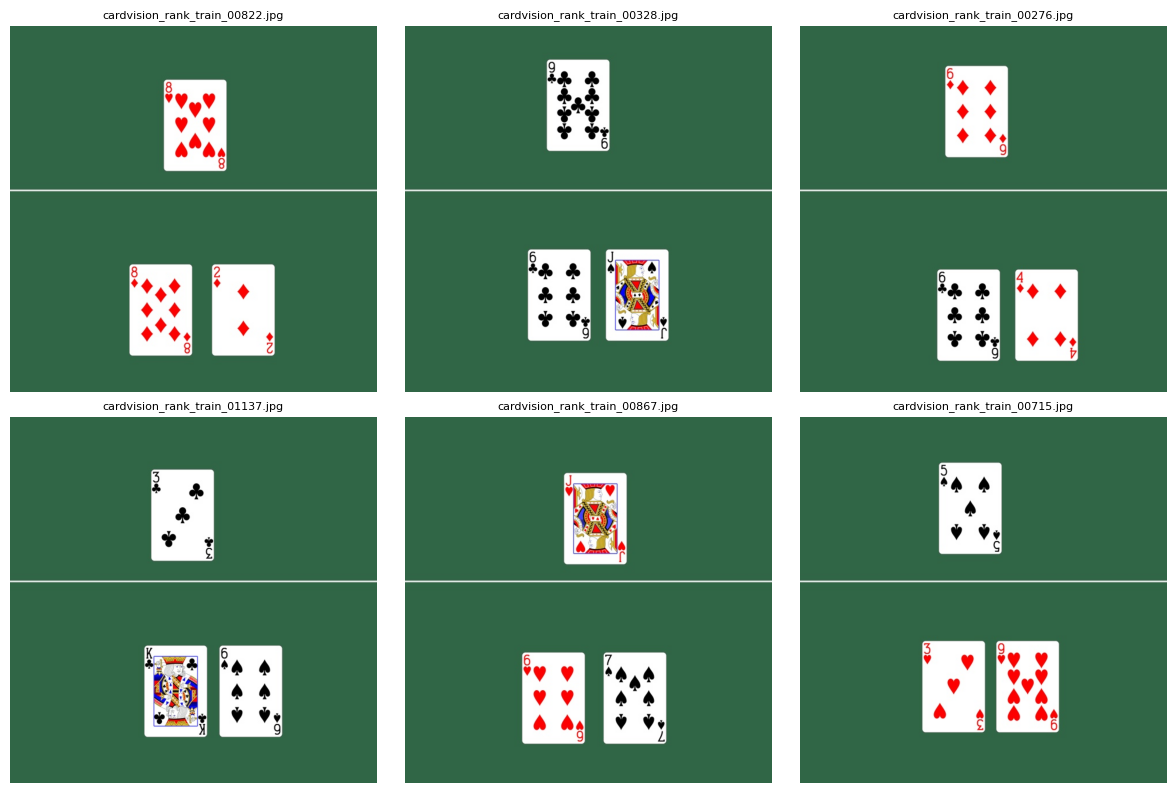

In [17]:
# Cell 17 - Preview generated rank-only synthetic images

sample_generated = random.sample(list(RANK_TRAIN_IMG_DIR.glob("*.jpg")), 6)

plt.figure(figsize=(12, 8))

for i, img_path in enumerate(sample_generated):
    img = Image.open(img_path).convert("RGB")
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(img_path.name, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
# Cell 18 - Train YOLOv8n rank-only model

rank_model = YOLO("yolov8n.pt")

rank_train_results = rank_model.train(
    data=str(RANK_DATA_YAML_PATH),
    epochs=25,
    imgsz=640,
    batch=16,
    name="cardvision_yolov8_ranks",
    patience=5,
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cardvision_yolo_rank/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cardvision_yolov8_ranks, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over

In [19]:
# Cell 19 - Validate trained rank-only YOLOv8 model

rank_best_model_path = "/content/runs/detect/cardvision_yolov8_ranks/weights/best.pt"

rank_trained_model = YOLO(rank_best_model_path)

rank_metrics = rank_trained_model.val(
    data=str(RANK_DATA_YAML_PATH),
    imgsz=640,
)

rank_metrics

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,183 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1271.5±641.2 MB/s, size: 34.7 KB)
val: Scanning /content/cardvision_yolo_rank/labels/val.cache... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 125.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 3.8it/s 5.0s
                   all        300        900      0.998          1      0.995      0.995
                     A         66         67      0.998          1      0.995      0.995
                     2         60         66      0.998          1      0.995      0.995
                     3         71         71      0.998          1      0.995      0.995
                     4         68         72      0.998          1      0.995      0.995
                     5         74    

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d748fa4a0c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.04504

In [20]:
# Cell 20 - Run rank-only YOLO inference on validation image

sample_rank_val_image = random.choice(list(RANK_VAL_IMG_DIR.glob("*.jpg")))

print("Testing image:", sample_rank_val_image)

rank_prediction_results = rank_trained_model.predict(
    source=str(sample_rank_val_image),
    conf=0.25,
    save=True,
)

rank_prediction_results

Testing image: /content/cardvision_yolo_rank/images/val/cardvision_rank_val_00078.jpg

image 1/1 /content/cardvision_yolo_rank/images/val/cardvision_rank_val_00078.jpg: 640x640 1 2, 1 6, 1 8, 7.2ms
Speed: 1.6ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'A', 1: '2', 2: '3', 3: '4', 4: '5', 5: '6', 6: '7', 7: '8', 8: '9', 9: '10', 10: 'J', 11: 'Q', 12: 'K'}
 obb: None
 orig_img: array([[[ 70, 102,  48],
         [ 70, 102,  48],
         [ 70, 102,  48],
         ...,
         [ 70, 102,  48],
         [ 70, 102,  48],
         [ 70, 102,  48]],
 
        [[ 70, 102,  48],
         [ 70, 102,  48],
         [ 70, 102,  48],
         ...,
         [ 70, 102,  48],
         [ 70, 102,  48],
         [ 70, 102,  48]],
 
        [[ 70, 102,  48],
         [ 70, 102,  48],
         [ 70, 102,  48],
         ...,
         [ 70, 102,  48],
         [ 70, 102,  48],
         [ 70, 102,  48]],
 
        ...,
 
        [[ 70, 102,  48],
         [ 70, 102,  48],
         [ 70, 102,  48],
         ...,
         [ 70, 102,  48],
         [ 70, 102,  48],
         [ 70, 102,  48]],
 
        [[ 70, 

Latest prediction directory: /content/runs/detect/predict


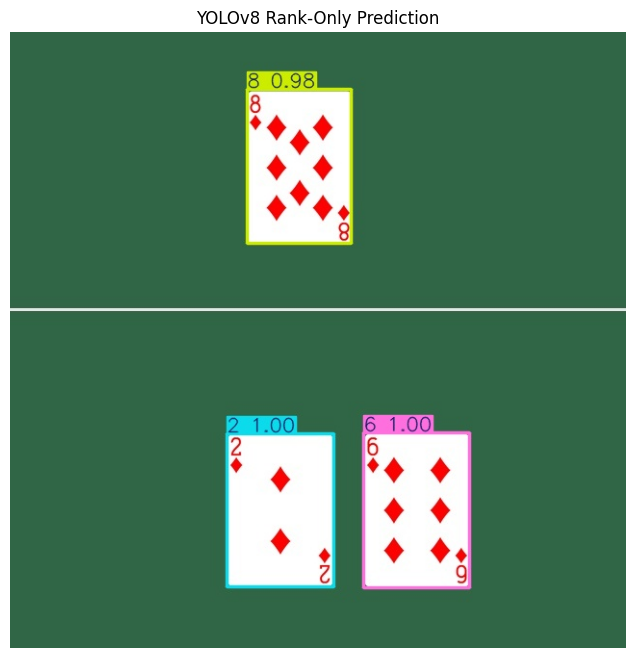

In [21]:
# Cell 21 - Display latest YOLO prediction image

predict_dirs = sorted(Path("/content/runs/detect").glob("predict*"), key=os.path.getmtime)

latest_predict_dir = predict_dirs[-1]
print("Latest prediction directory:", latest_predict_dir)

predicted_images = list(latest_predict_dir.glob("*.jpg"))

if not predicted_images:
    raise FileNotFoundError("No predicted images found.")

pred_img = Image.open(predicted_images[0]).convert("RGB")

plt.figure(figsize=(10, 8))
plt.imshow(pred_img)
plt.axis("off")
plt.title("YOLOv8 Rank-Only Prediction")
plt.show()

In [22]:
# Cell 22 - Dealer/player zone and detection helpers

dealer_zone_rank = {
    "name": "dealer",
    "x1": 0,
    "y1": 0,
    "x2": IMG_W,
    "y2": IMG_H * 0.45,
}

player_zone_rank = {
    "name": "player",
    "x1": 0,
    "y1": IMG_H * 0.45,
    "x2": IMG_W,
    "y2": IMG_H,
}


def bbox_center(bbox):
    cx = (bbox["x1"] + bbox["x2"]) / 2
    cy = (bbox["y1"] + bbox["y2"]) / 2
    return cx, cy


def point_in_zone(cx, cy, zone):
    return zone["x1"] <= cx <= zone["x2"] and zone["y1"] <= cy <= zone["y2"]


def assign_card_to_zone(card_detection, dealer_zone, player_zone):
    cx, cy = bbox_center(card_detection["bbox"])

    if point_in_zone(cx, cy, dealer_zone):
        return "dealer"

    if point_in_zone(cx, cy, player_zone):
        return "player"

    return "unknown"


def group_detections_by_zone(card_detections, dealer_zone, player_zone):
    grouped = {"dealer": [], "player": [], "unknown": []}

    for detection in card_detections:
        zone_name = assign_card_to_zone(detection, dealer_zone, player_zone)
        grouped[zone_name].append(detection)

    return grouped


def yolo_result_to_cardvision_detections(yolo_result):
    detections = []

    boxes = yolo_result.boxes

    if boxes is None:
        return detections

    for box in boxes:
        class_id = int(box.cls[0].item())
        confidence = float(box.conf[0].item())
        x1, y1, x2, y2 = box.xyxy[0].tolist()

        rank = id_to_rank[class_id]

        detections.append({
            "rank": rank,
            "bbox": {
                "x1": float(x1),
                "y1": float(y1),
                "x2": float(x2),
                "y2": float(y2),
            },
            "confidence": confidence,
        })

    return detections


def recommendation_from_detections(grouped_detections):
    dealer_cards = grouped_detections.get("dealer", [])
    player_cards = grouped_detections.get("player", [])

    if not dealer_cards:
        raise ValueError("No dealer card detected.")

    if len(player_cards) < 2:
        raise ValueError("At least two player cards are required.")

    dealer_upcard = dealer_cards[0]["rank"]
    player_ranks = [card["rank"] for card in player_cards]

    return cardvision_recommend(player_ranks, dealer_upcard)

In [23]:
# Cell 23 - Visualization helper

def visualize_detections(image, card_detections, dealer_zone=None, player_zone=None):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image)
    ax.axis("off")

    if dealer_zone:
        dealer_rect = patches.Rectangle(
            (dealer_zone["x1"], dealer_zone["y1"]),
            dealer_zone["x2"] - dealer_zone["x1"],
            dealer_zone["y2"] - dealer_zone["y1"],
            linewidth=2,
            edgecolor="blue",
            facecolor="none",
        )
        ax.add_patch(dealer_rect)
        ax.text(10, 30, "Dealer Zone", fontsize=10, color="blue", bbox=dict(facecolor="white", alpha=0.8))

    if player_zone:
        player_rect = patches.Rectangle(
            (player_zone["x1"], player_zone["y1"]),
            player_zone["x2"] - player_zone["x1"],
            player_zone["y2"] - player_zone["y1"],
            linewidth=2,
            edgecolor="green",
            facecolor="none",
        )
        ax.add_patch(player_rect)
        ax.text(10, player_zone["y1"] + 30, "Player Zone", fontsize=10, color="green", bbox=dict(facecolor="white", alpha=0.8))

    for detection in card_detections:
        bbox = detection["bbox"]
        label = f"{detection['rank']} ({detection['confidence']:.2f})"

        rect = patches.Rectangle(
            (bbox["x1"], bbox["y1"]),
            bbox["x2"] - bbox["x1"],
            bbox["y2"] - bbox["y1"],
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(bbox["x1"], bbox["y1"] - 8, label, fontsize=10, color="red", bbox=dict(facecolor="white", alpha=0.85))

    plt.title("CardVision Detection Visualization")
    plt.show()

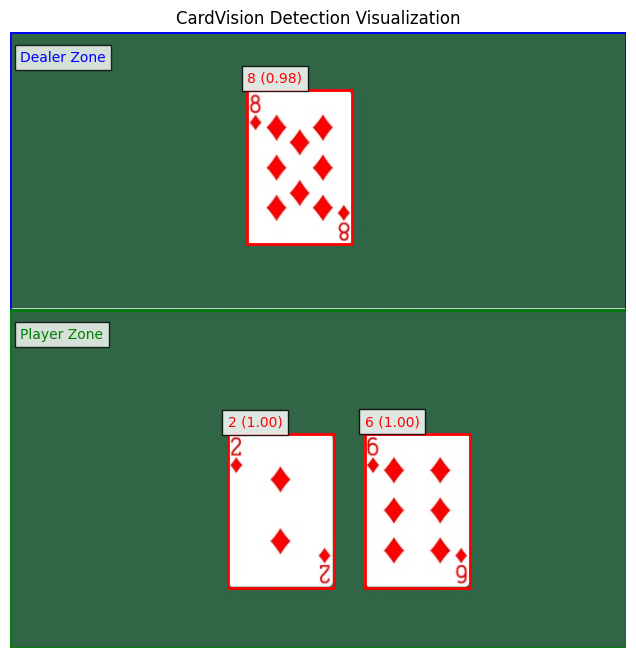

Detected dealer ranks: ['8']
Detected player ranks: ['2', '6']
Unknown detections: []

CardVision Recommendation
-------------------------
Player hand: ['2', '6'] (hard 8)
Dealer upcard: 8
Recommended action: Hit


,player_cards,player_total,hand_type,dealer_upcard,recommended_action
0,"[2, 6]",8,hard,8,Hit


In [24]:
# Cell 24 - Full CardVision YOLO demo

def run_cardvision_yolo_demo(image_path, model, dealer_zone, player_zone, conf=0.25):
    image = Image.open(image_path).convert("RGB")

    yolo_results = model.predict(
        source=str(image_path),
        conf=conf,
        save=False,
        verbose=False,
    )

    detections = yolo_result_to_cardvision_detections(yolo_results[0])

    visualize_detections(
        image,
        detections,
        dealer_zone=dealer_zone,
        player_zone=player_zone,
    )

    grouped = group_detections_by_zone(detections, dealer_zone, player_zone)

    print("Detected dealer ranks:", [card["rank"] for card in grouped["dealer"]])
    print("Detected player ranks:", [card["rank"] for card in grouped["player"]])
    print("Unknown detections:", [card["rank"] for card in grouped["unknown"]])
    print()

    result = recommendation_from_detections(grouped)

    print("CardVision Recommendation")
    print("-------------------------")
    print(f"Player hand: {result['player_cards']} ({result['hand_type']} {result['player_total']})")
    print(f"Dealer upcard: {result['dealer_upcard']}")
    print(f"Recommended action: {result['recommended_action']}")

    return show_cardvision_result(result)


demo_df = run_cardvision_yolo_demo(
    sample_rank_val_image,
    rank_trained_model,
    dealer_zone_rank,
    player_zone_rank,
    conf=0.25,
)

demo_df

In [25]:
# Cell 25 - Save final model and result artifacts

RESULTS_DIR = Path("/content/cardvision_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FINAL_MODEL_PATH = Path("/content/runs/detect/cardvision_yolov8_ranks/weights/best.pt")
MODEL_COPY_PATH = RESULTS_DIR / "cardvision_yolov8_rank_best.pt"

if FINAL_MODEL_PATH.exists():
    shutil.copy(FINAL_MODEL_PATH, MODEL_COPY_PATH)
    print("Copied final model to:", MODEL_COPY_PATH)
    print("Model size MB:", round(MODEL_COPY_PATH.stat().st_size / (1024 * 1024), 2))
else:
    raise FileNotFoundError("Final model weights not found.")

demo_csv_path = RESULTS_DIR / "cardvision_demo_recommendation.csv"
demo_df.to_csv(demo_csv_path, index=False)

print("Saved demo CSV to:", demo_csv_path)

Copied final model to: /content/cardvision_results/cardvision_yolov8_rank_best.pt
Model size MB: 5.96
Saved demo CSV to: /content/cardvision_results/cardvision_demo_recommendation.csv


## Final Notebook Summary

This notebook demonstrates an end-to-end CardVision V1 prototype.

### Completed Pipeline

1. Downloaded a Kaggle 52-card PNG dataset.
2. Parsed card filenames into card labels.
3. Converted full card labels into rank-only labels.
4. Generated a synthetic blackjack-table YOLO dataset.
5. Trained a YOLOv8n rank-only object detection model.
6. Detected card ranks from synthetic validation images.
7. Assigned detected cards to dealer and player zones.
8. Parsed the blackjack board state.
9. Produced a basic strategy recommendation: Hit, Stand, Double, or Split.

### V1 Scope

CardVision V1 intentionally uses rank-only detection because blackjack strategy decisions do not depend on suit. The system supports one dealer upcard and one player hand.

### Current Limitations

- Uses synthetic images instead of real camera frames.
- Assumes dealer cards appear in the top zone and player cards appear in the bottom zone.
- Does not support multiple players, insurance, surrender, or post-split hand tracking.
- Future work should test on real photos and expand layout robustness.

### Final Output

Image → YOLOv8 rank detection → dealer/player grouping → blackjack strategy recommendation.